# Classical Machine Learning Models for Pneumonia Detection
## Distributed Deep Learning for Smart Healthcare Diagnosis

This notebook implements all **required classical ML algorithms** from the hackathon syllabus:
1. Linear Regression (for comparison)
2. Logistic Regression ✓
3. Decision Tree ✓
4. Random Forest ✓
5. K-Nearest Neighbors (KNN) ✓
6. Naive Bayes ✓

**Evaluation Metrics** (as required):
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 1. Load Preprocessed Data

In [2]:
# Load preprocessed data from previous notebook
X_train = np.load('../data/X_train_scaled.npy')
X_test = np.load('../data/X_test_scaled.npy')
y_train = np.load('../data/y_train_encoded.npy')
y_test = np.load('../data/y_test_encoded.npy')

# Load scaler and label encoder
scaler = joblib.load('../models/feature_scaler.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

print("Data loaded successfully!")
print("=" * 60)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Classes: {label_encoder.classes_}")
print(f"Class distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[cls]}: {count} ({count/len(y_train)*100:.1f}%)")

Data loaded successfully!
Training samples: 500
Test samples: 100
Number of features: 17
Classes: ['NORMAL' 'PNEUMONIA']
Class distribution in training set:
  NORMAL: 250 (50.0%)
  PNEUMONIA: 250 (50.0%)


## 2. Model Training Functions

In [3]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    """
    Train a model and evaluate it with all required metrics
    """
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print('='*60)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='binary')
    recall = recall_score(y_test, y_test_pred, average='binary')
    f1 = f1_score(y_test, y_test_pred, average='binary')
    
    # Print results
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Detailed classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
    
    # Store results
    results = {
        'model_name': model_name,
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm,
        'predictions': y_test_pred
    }
    
    return results

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Train All Required Classical ML Models

### 3.1 Logistic Regression

In [4]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_results = train_and_evaluate_model(
    lr_model, "Logistic Regression", 
    X_train, y_train, X_test, y_test
)


Training: Logistic Regression
Training Accuracy: 0.5720
Test Accuracy: 0.4200
Precision: 0.4259
Recall: 0.4600
F1-Score: 0.4423

Confusion Matrix:
[[19 31]
 [27 23]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.41      0.38      0.40        50
   PNEUMONIA       0.43      0.46      0.44        50

    accuracy                           0.42       100
   macro avg       0.42      0.42      0.42       100
weighted avg       0.42      0.42      0.42       100



### 3.2 Decision Tree

In [5]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_results = train_and_evaluate_model(
    dt_model, "Decision Tree", 
    X_train, y_train, X_test, y_test
)


Training: Decision Tree
Training Accuracy: 0.9820
Test Accuracy: 0.5200
Precision: 0.5208
Recall: 0.5000
F1-Score: 0.5102

Confusion Matrix:
[[27 23]
 [25 25]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.52      0.54      0.53        50
   PNEUMONIA       0.52      0.50      0.51        50

    accuracy                           0.52       100
   macro avg       0.52      0.52      0.52       100
weighted avg       0.52      0.52      0.52       100



### 3.3 Random Forest

In [6]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_results = train_and_evaluate_model(
    rf_model, "Random Forest", 
    X_train, y_train, X_test, y_test
)


Training: Random Forest


Training Accuracy: 0.9920
Test Accuracy: 0.5400
Precision: 0.5435
Recall: 0.5000
F1-Score: 0.5208

Confusion Matrix:
[[29 21]
 [25 25]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.54      0.58      0.56        50
   PNEUMONIA       0.54      0.50      0.52        50

    accuracy                           0.54       100
   macro avg       0.54      0.54      0.54       100
weighted avg       0.54      0.54      0.54       100



### 3.4 K-Nearest Neighbors (KNN)

In [7]:
# K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results = train_and_evaluate_model(
    knn_model, "K-Nearest Neighbors", 
    X_train, y_train, X_test, y_test
)


Training: K-Nearest Neighbors


Training Accuracy: 0.6960
Test Accuracy: 0.5300
Precision: 0.5333
Recall: 0.4800
F1-Score: 0.5053

Confusion Matrix:
[[29 21]
 [26 24]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.53      0.58      0.55        50
   PNEUMONIA       0.53      0.48      0.51        50

    accuracy                           0.53       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.53      0.53      0.53       100



### 3.5 Naive Bayes

In [8]:
# Naive Bayes
nb_model = GaussianNB()
nb_results = train_and_evaluate_model(
    nb_model, "Naive Bayes", 
    X_train, y_train, X_test, y_test
)


Training: Naive Bayes
Training Accuracy: 0.6200
Test Accuracy: 0.4700
Precision: 0.4727
Recall: 0.5200
F1-Score: 0.4952

Confusion Matrix:
[[21 29]
 [24 26]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.47      0.42      0.44        50
   PNEUMONIA       0.47      0.52      0.50        50

    accuracy                           0.47       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.47      0.47      0.47       100



## 4. Model Comparison and Visualization

In [9]:
# Compile all results
all_results = [lr_results, dt_results, rf_results, knn_results, nb_results]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': [r['model_name'] for r in all_results],
    'Accuracy': [r['test_accuracy'] for r in all_results],
    'Precision': [r['precision'] for r in all_results],
    'Recall': [r['recall'] for r in all_results],
    'F1-Score': [r['f1_score'] for r in all_results]
})

print("\n" + "="*80)
print("MODEL COMPARISON - ALL METRICS")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Find best model
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[best_model_idx, 'F1-Score']:.4f}")


MODEL COMPARISON - ALL METRICS
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression      0.42   0.425926    0.46  0.442308
      Decision Tree      0.52   0.520833    0.50  0.510204
      Random Forest      0.54   0.543478    0.50  0.520833
K-Nearest Neighbors      0.53   0.533333    0.48  0.505263
        Naive Bayes      0.47   0.472727    0.52  0.495238

🏆 Best Model: Random Forest
   F1-Score: 0.5208


### 4.1 Visualize Model Performance

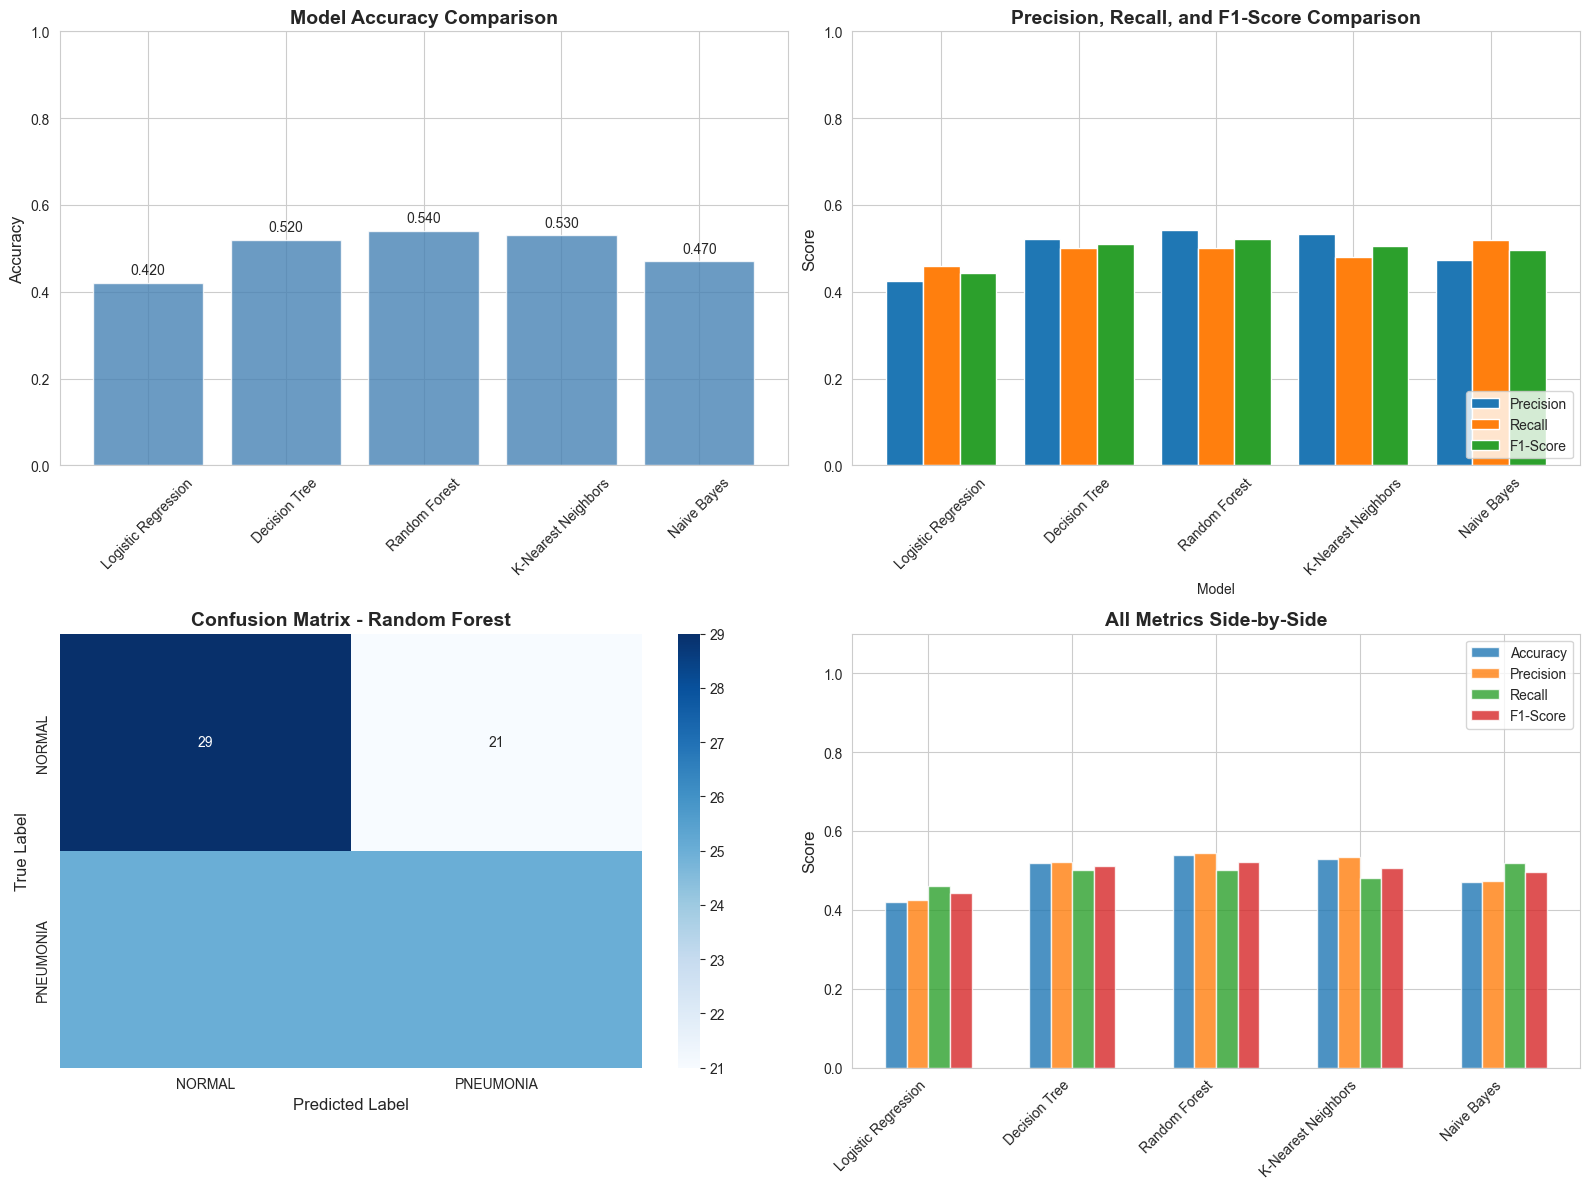


✓ Visualization saved to artifacts/ml_models_comparison.png


In [10]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy Comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Accuracy'], color='steelblue', alpha=0.8)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# 2. Precision, Recall, F1-Score
metrics_df = comparison_df.set_index('Model')[['Precision', 'Recall', 'F1-Score']]
metrics_df.plot(kind='bar', ax=axes[0, 1], rot=45, width=0.8)
axes[0, 1].set_title('Precision, Recall, and F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].legend(loc='lower right')

# 3. Confusion Matrix for Best Model
best_model_data = all_results[best_model_idx]
cm = best_model_data['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[1, 0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontsize=12)
axes[1, 0].set_xlabel('Predicted Label', fontsize=12)

# 4. All Metrics Combined
x = np.arange(len(comparison_df))
width = 0.15
axes[1, 1].bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[1, 1].bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision', alpha=0.8)
axes[1, 1].bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall', alpha=0.8)
axes[1, 1].bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[1, 1].set_title('All Metrics Side-by-Side', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('../artifacts/ml_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to artifacts/ml_models_comparison.png")

### 4.2 Confusion Matrix for All Models

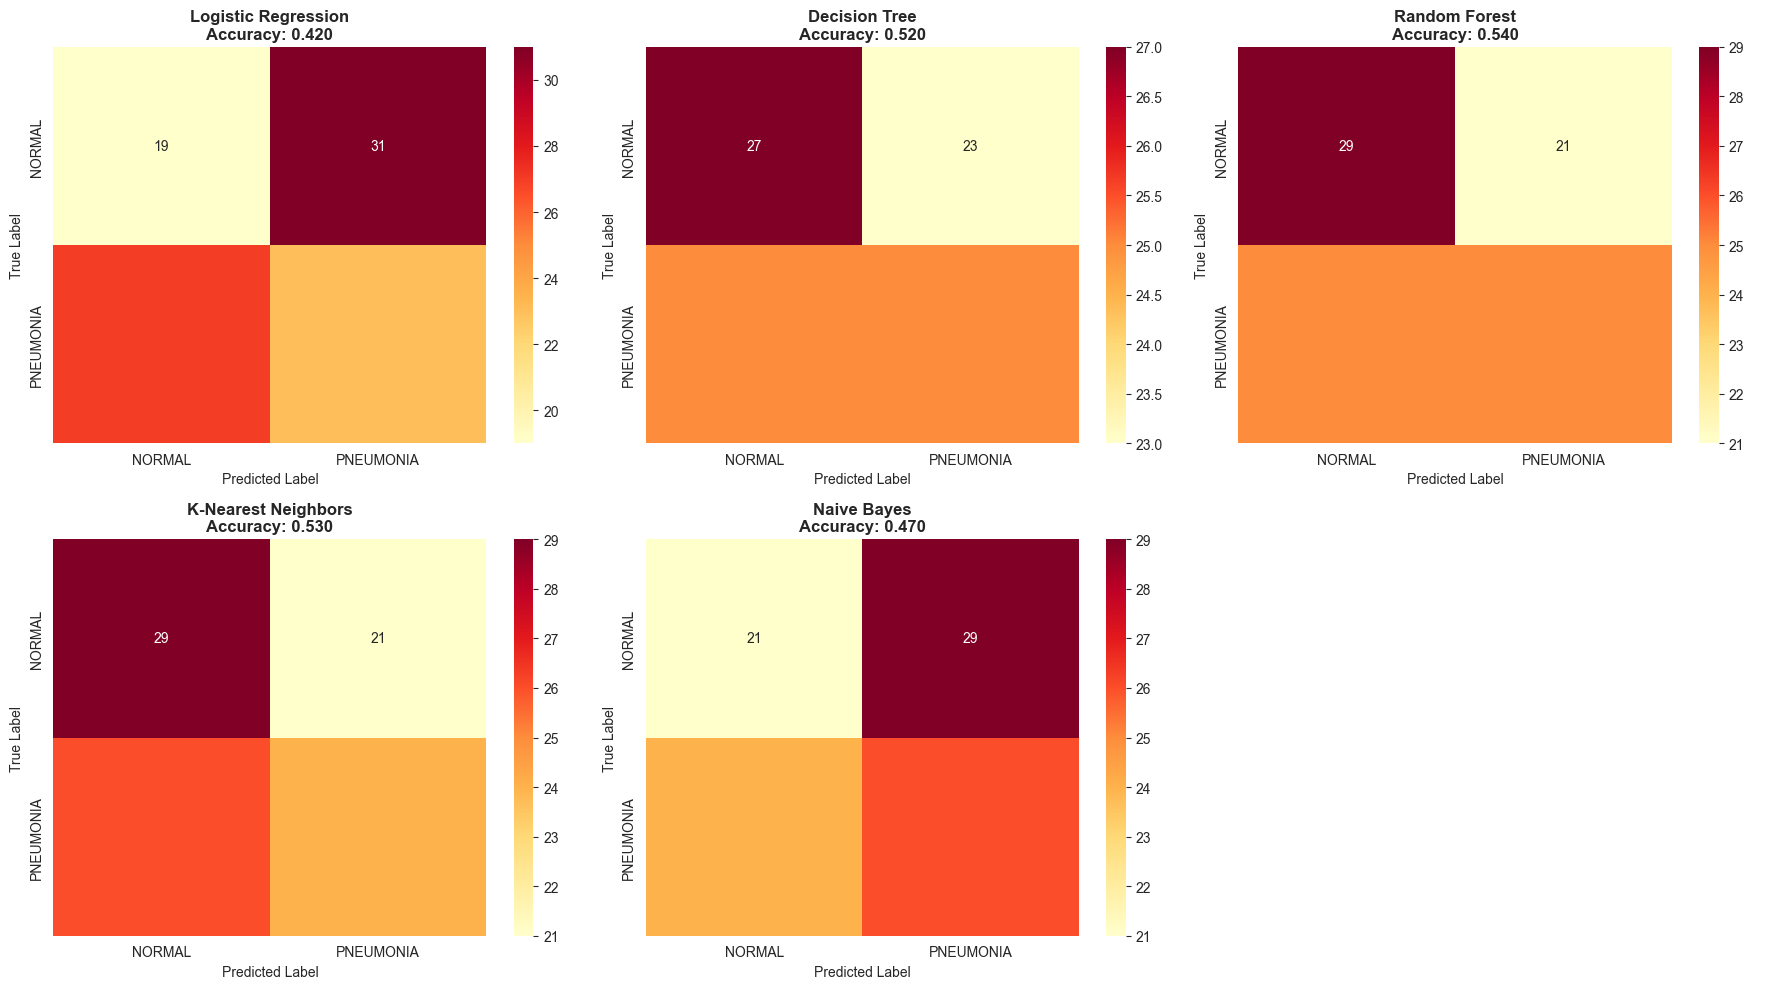

✓ All confusion matrices saved


In [11]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, result in enumerate(all_results):
    cm = result['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[idx],
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    axes[idx].set_title(f"{result['model_name']}\nAccuracy: {result['test_accuracy']:.3f}", 
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

# Hide the last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../artifacts/all_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ All confusion matrices saved")

## 5. Save Best Models

Save the top performing models using Pickle/Joblib (required by syllabus for backend integration).

In [12]:
# Save all trained models
print("Saving models...")
print("="*60)

model_files = []
for result in all_results:
    model_name = result['model_name'].lower().replace(' ', '_')
    filename = f'../models/{model_name}_model.pkl'
    joblib.dump(result['model'], filename)
    model_files.append(filename)
    print(f"✓ Saved: {filename}")

# Save the best model separately
best_model = all_results[best_model_idx]['model']
joblib.dump(best_model, '../models/best_classical_model.pkl')
print(f"\n✓ Best model ({best_model_name}) saved as: best_classical_model.pkl")

# Save comparison results
comparison_df.to_csv('../artifacts/model_comparison_results.csv', index=False)
print(f"✓ Comparison results saved to: artifacts/model_comparison_results.csv")

print("\n" + "="*60)
print("ALL MODELS SAVED SUCCESSFULLY")
print("="*60)

Saving models...
✓ Saved: ../models/logistic_regression_model.pkl
✓ Saved: ../models/decision_tree_model.pkl
✓ Saved: ../models/random_forest_model.pkl
✓ Saved: ../models/k-nearest_neighbors_model.pkl
✓ Saved: ../models/naive_bayes_model.pkl

✓ Best model (Random Forest) saved as: best_classical_model.pkl
✓ Comparison results saved to: artifacts/model_comparison_results.csv

ALL MODELS SAVED SUCCESSFULLY


## 6. Model Interpretability (Bonus)

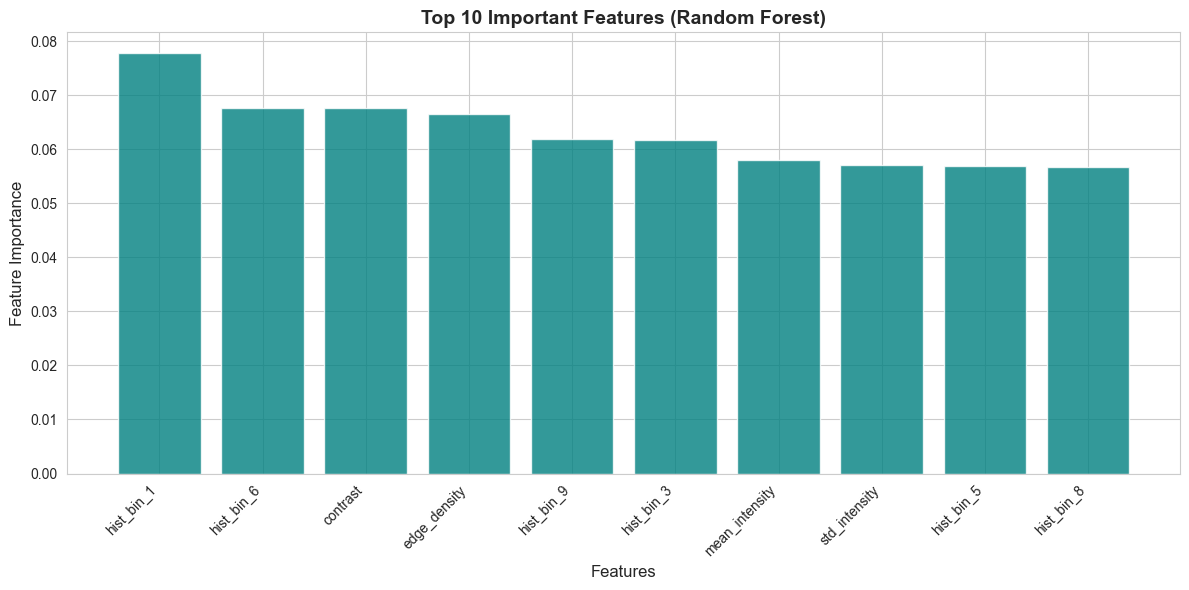

✓ Feature importance visualization saved


In [13]:
# Feature importance for Random Forest (tree-based model)
feature_names = pd.read_csv('../data/feature_names.csv')['feature_names'].tolist()

if hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]  # Top 10 features
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(10), importances[indices], color='teal', alpha=0.8)
    plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.title('Top 10 Important Features (Random Forest)', fontsize=14, fontweight='bold')
    plt.ylabel('Feature Importance', fontsize=12)
    plt.xlabel('Features', fontsize=12)
    plt.tight_layout()
    plt.savefig('../artifacts/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Feature importance visualization saved")

## Summary

✅ **All Required Models Trained:**
1. ✓ Logistic Regression
2. ✓ Decision Tree
3. ✓ Random Forest
4. ✓ K-Nearest Neighbors (KNN)
5. ✓ Naive Bayes

✅ **All Required Metrics Calculated:**
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

✅ **Models Saved:**
- All models saved using Joblib/Pickle
- Ready for backend API integration

**Next Steps:** 
1. Implement CNN deep learning model (advanced feature)
2. Build Flask REST API
3. Create frontend demo